In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from supabase import create_client
from sklearn.model_selection import train_test_split

load_dotenv()
url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_KEY")
supabase = create_client(url, key)

all_rows = []
start = 0
batch_size = 1000

while True:
    response = supabase.table("telco_churn").select("*").range(start, start + batch_size - 1).execute()
    if not response.data:
        break
    all_rows.extend(response.data)
    start += batch_size

df = pd.DataFrame(all_rows)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

eda_df = df.copy()

## Tjänstepaket. antal tilläggstjänster vs churn.

Räknar ihop hur många av de 6 tilläggstjänsterna (OnlineSecurity, OnlineBackup,
DeviceProtection, TechSupport, StreamingTV, StreamingMovies) varje kund har,
till en ny kolumn `num_services` (0–6). Grupperar sedan kunderna efter det
antalet och räknar churn-andelen i varje grupp, för att se om churn-risken
sjunker ju fler tjänster en kund har.

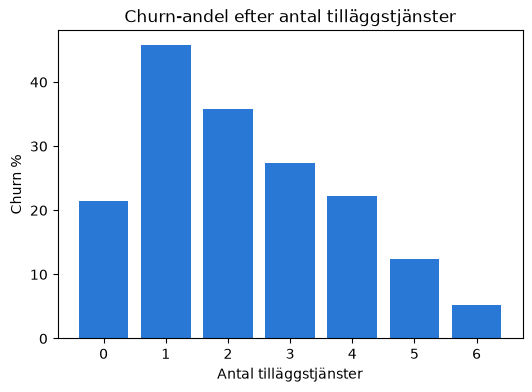

In [20]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

eda_df["num_services"] = (eda_df[service_cols] == "Yes").sum(axis=1)

churn_by_services = eda_df.groupby("num_services")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(churn_by_services.index.astype(str), churn_by_services.values, color="#2a78d6")
ax.set_xlabel("Antal tilläggstjänster")
ax.set_ylabel("Churn %")
ax.set_title("Churn-andel efter antal tilläggstjänster")
plt.show()

## Tenure-kohorter. churn över kundlivscykeln.

Delar in varje kunds `tenure` (antal månader som kund) i en av fyra grupper:
0–12, 12–24, 24–48 och 48–72 månader (`pd.cut`). Grupperar sedan kunderna
efter tenure-grupp och räknar churn-andelen i varje grupp, för att se hur
churn-risken förändras ju längre en kund varit hos företaget.

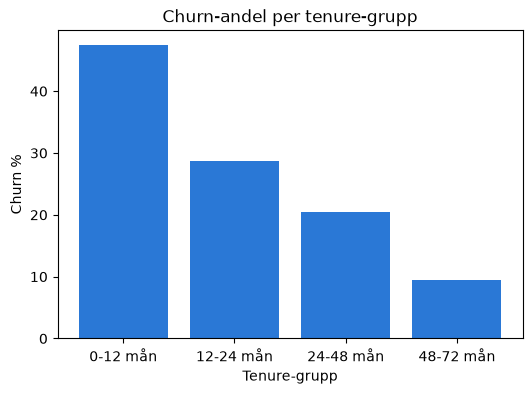

In [21]:
bins = [0, 12, 24, 48, 72]
labels = ["0-12 mån", "12-24 mån", "24-48 mån", "48-72 mån"]

eda_df["tenure_group"] = pd.cut(eda_df["tenure"], bins=bins, labels=labels, include_lowest=True)

churn_by_tenure = eda_df.groupby("tenure_group", observed=True)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(churn_by_tenure.index.astype(str), churn_by_tenure.values, color="#2a78d6")
ax.set_xlabel("Tenure-grupp")
ax.set_ylabel("Churn %")
ax.set_title("Churn-andel per tenure-grupp")
plt.show()

## Contract × PaymentMethod. churn per kombination.

Grupperar kunderna på **två** kolumner samtidigt (`Contract` och
`PaymentMethod`) istället för bara en, och räknar churn-andelen för varje
kombination. `.unstack()` gör om resultatet till en tabell (Contract som
rader, PaymentMethod som kolumner), som sedan ritas som en heatmap — mörkare
ruta = högre churn-andel. Syftet är att se om det är *samspelet* mellan
avtalstyp och betalningssätt som driver churn, inte bara varje variabel
för sig.

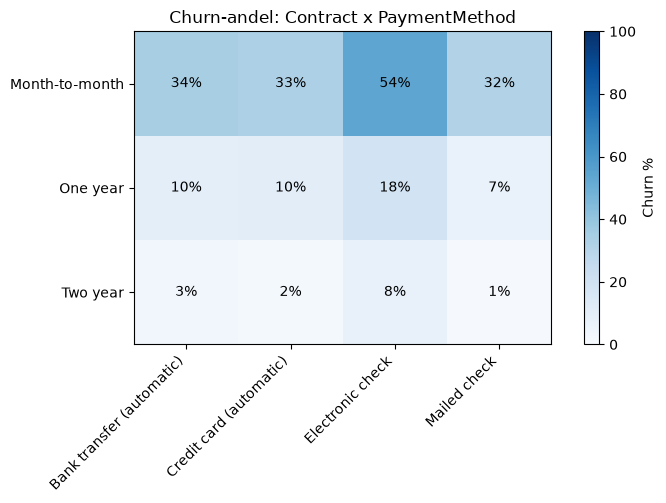

In [22]:
combo = eda_df.groupby(["Contract", "PaymentMethod"])["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
combo_table = combo.unstack()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(combo_table, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(combo_table.columns)))
ax.set_xticklabels(combo_table.columns, rotation=45, ha="right")
ax.set_yticks(range(len(combo_table.index)))
ax.set_yticklabels(combo_table.index)
for i in range(len(combo_table.index)):
    for j in range(len(combo_table.columns)):
        val = combo_table.iloc[i, j]
        text = f"{val:.0f}%" if pd.notna(val) else ""
        ax.text(j, i, text, ha="center", va="center")
plt.colorbar(im, label="Churn %")
plt.title("Churn-andel: Contract x PaymentMethod")
plt.tight_layout()
plt.show()

## Kundvärde. MonthlyCharges vs TotalCharges.

En scatterplot med en prick per kund: x-axeln är `MonthlyCharges`
(vad kunden betalar per månad), y-axeln `TotalCharges` (vad kunden
betalat totalt sen start), färgat efter Churn. Formen på punktmolnet
(en solfjäder) kommer av att `TotalCharges` ökar med både månadsavgift
och tenure tillsammans — så grafen låter oss se churn-mönster utifrån
båda faktorerna på en gång, istället för var för sig som i tidigare
block.

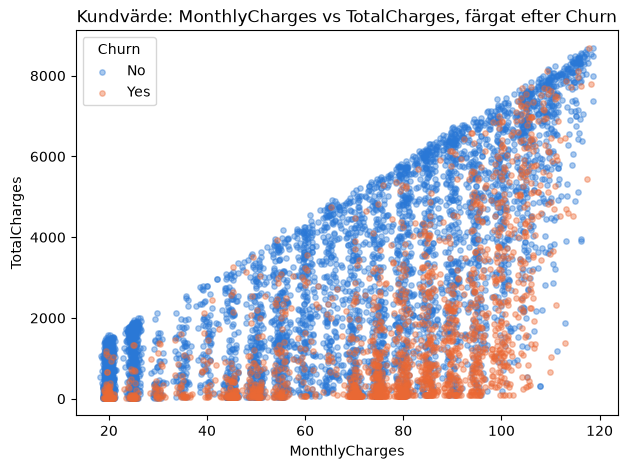

In [23]:
colors_map = {"No": "#2a78d6", "Yes": "#eb6834"}

fig, ax = plt.subplots(figsize=(7, 5))
for churn_value, color in colors_map.items():
    subset = eda_df[eda_df["Churn"] == churn_value]
    ax.scatter(subset["MonthlyCharges"], subset["TotalCharges"],
               color=color, alpha=0.4, s=15, label=churn_value)

ax.set_xlabel("MonthlyCharges")
ax.set_ylabel("TotalCharges")
ax.set_title("Kundvärde: MonthlyCharges vs TotalCharges, färgat efter Churn")
ax.legend(title="Churn")
plt.show()

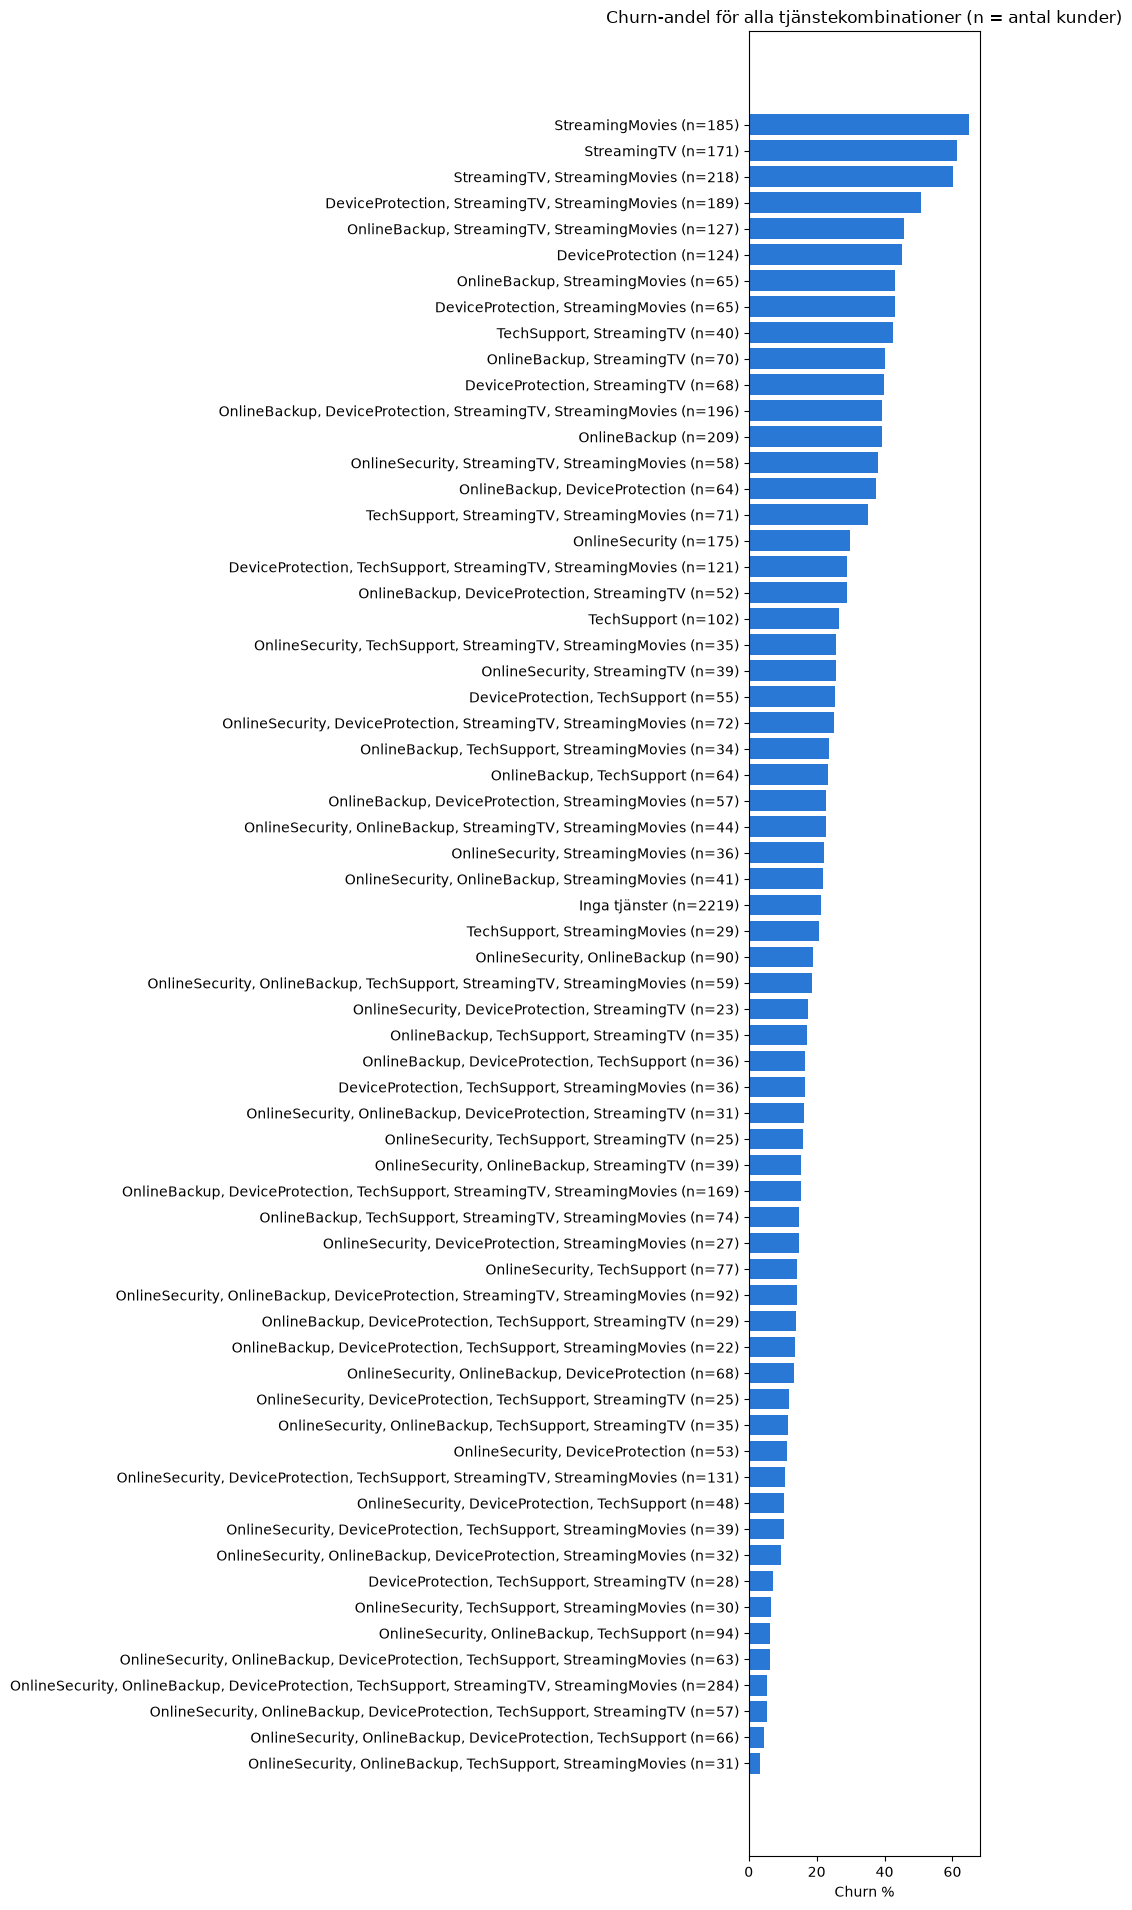

In [24]:
def combo_label(row):
    has = [col for col in service_cols if row[col] == "Yes"]
    return ", ".join(has) if has else "Inga tjänster"

eda_df["service_combo"] = eda_df[service_cols].apply(combo_label, axis=1)

combo_counts = eda_df["service_combo"].value_counts()
top_combos = combo_counts.head(10).index

combo_churn = eda_df[eda_df["service_combo"].isin(top_combos)].groupby("service_combo")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
combo_churn = combo_churn.reindex(top_combos)

combo_stats = eda_df.groupby("service_combo")["Churn"].agg(
    churn_pct=lambda s: (s == "Yes").mean() * 100,
    n="count"
).sort_values("churn_pct")

labels = [f"{combo} (n={n})" for combo, n in zip(combo_stats.index, combo_stats["n"])]

fig, ax = plt.subplots(figsize=(10, len(combo_stats) * 0.3))
ax.barh(labels, combo_stats["churn_pct"], color="#2a78d6")
ax.set_xlabel("Churn %")
ax.set_title("Churn-andel för alla tjänstekombinationer (n = antal kunder)")
plt.tight_layout()
plt.show()


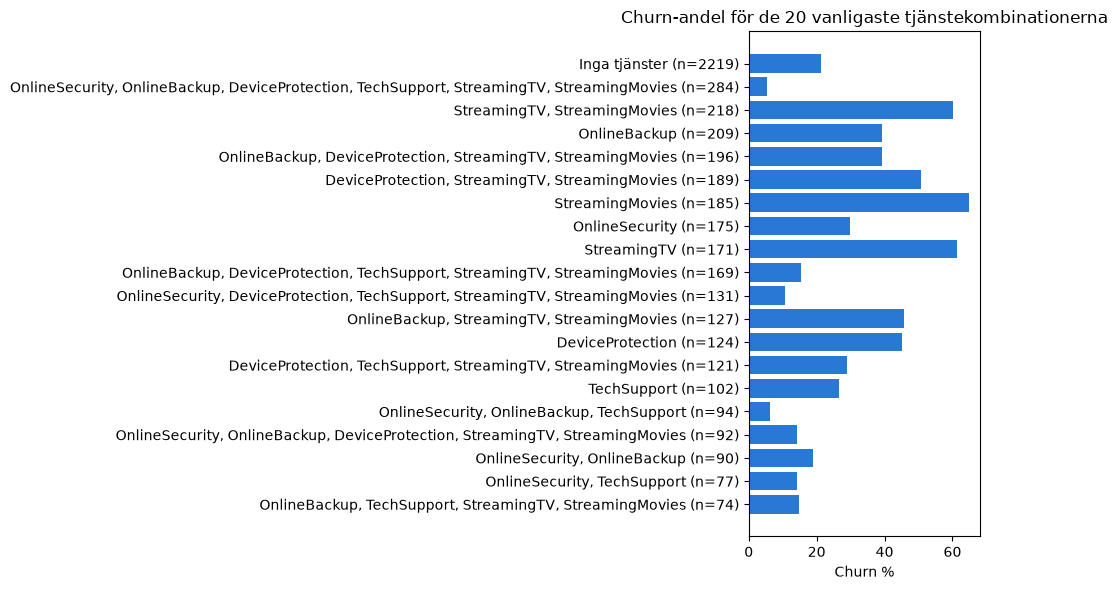

In [25]:
top20_by_count = combo_stats.sort_values("n", ascending=False).head(20)
top20_by_count = top20_by_count.sort_values("n")

labels_top20 = [f"{combo} (n={n})" for combo, n in zip(top20_by_count.index, top20_by_count["n"])]

fig, ax = plt.subplots(figsize=(10, len(top20_by_count) * 0.3))
ax.barh(labels_top20, top20_by_count["churn_pct"], color="#2a78d6")
ax.set_xlabel("Churn %")
ax.set_title("Churn-andel för de 20 vanligaste tjänstekombinationerna")
plt.tight_layout()
plt.show()


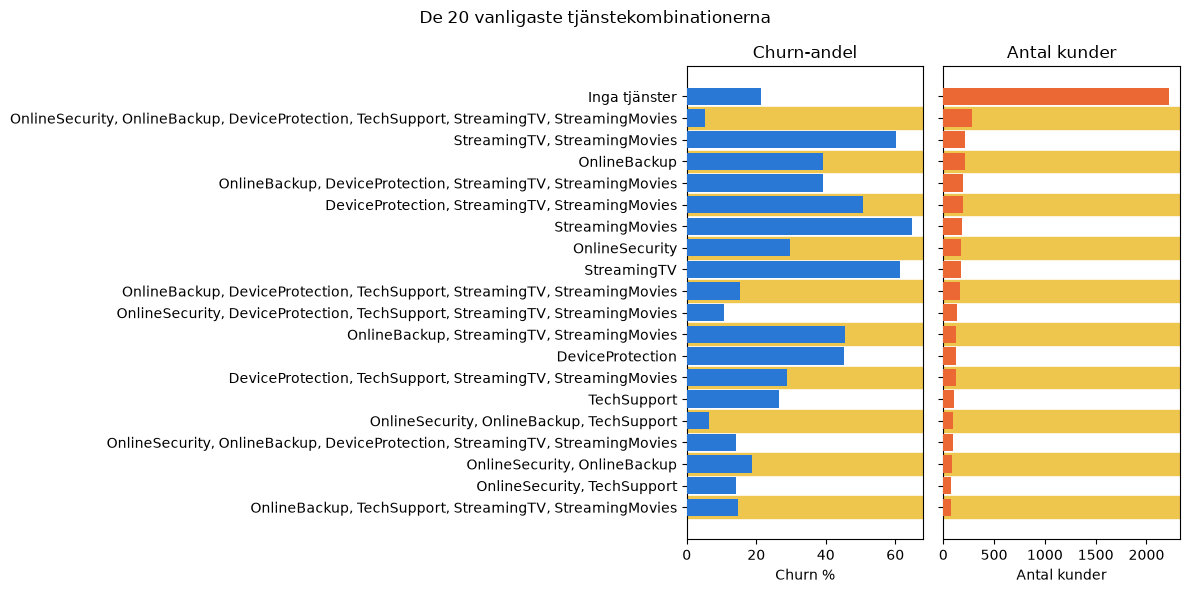

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, len(top20_by_count) * 0.3), sharey=True)

for ax in (ax1, ax2):
    for i in range(len(top20_by_count)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="#eec64e", zorder=0)

ax1.barh(top20_by_count.index, top20_by_count["churn_pct"], color="#2a78d6", zorder=3)
ax1.set_xlabel("Churn %")
ax1.set_title("Churn-andel")

ax2.barh(top20_by_count.index, top20_by_count["n"], color="#eb6834", zorder=3)
ax2.set_xlabel("Antal kunder")
ax2.set_title("Antal kunder")

plt.suptitle("De 20 vanligaste tjänstekombinationerna")
plt.tight_layout()
plt.show()

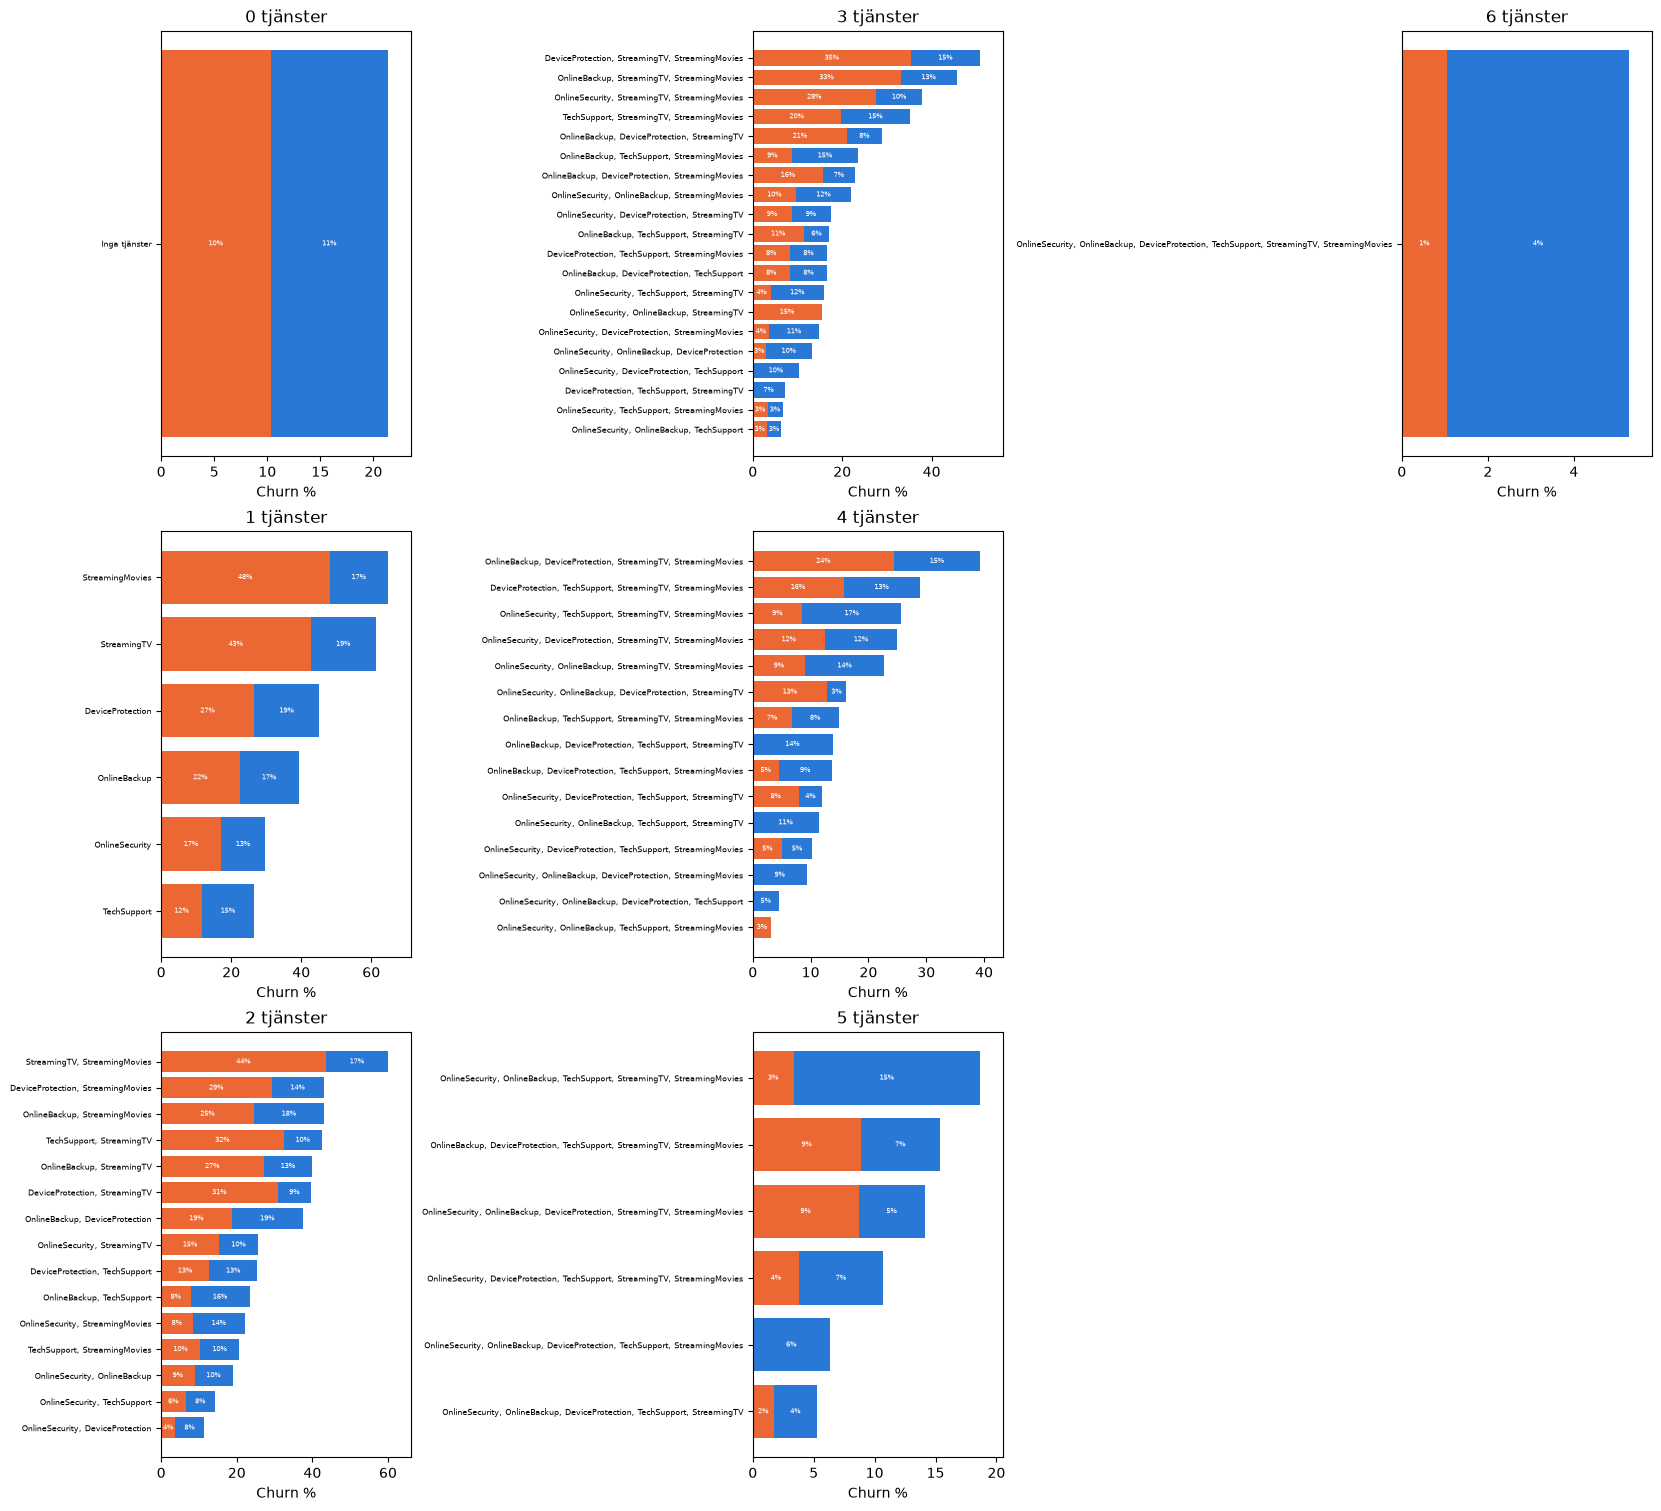

In [27]:
num_groups = sorted(eda_df["num_services"].unique())
n_groups = len(num_groups)
n_rows = 3
n_cols = -(-n_groups // n_rows)

combo_full = eda_df.groupby(["num_services", "service_combo"]).apply(
    lambda g: pd.Series({
        "churn_pct": (g["Churn"] == "Yes").mean() * 100,
        "ec_churn_pct": ((g["Churn"] == "Yes") & (g["PaymentMethod"] == "Electronic check")).mean() * 100,
        "n": len(g)
    }),
    include_groups=False
)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.5, n_rows * 5), constrained_layout=True)
axes = axes.flatten(order="F")

for i, num in enumerate(num_groups):
    ax = axes[i]
    table = combo_full.loc[num].sort_values("churn_pct")
    y_pos = range(len(table))

    ax.barh(y_pos, table["churn_pct"], color="#2a78d6")
    ax.barh(y_pos, table["ec_churn_pct"], color="#eb6834")

    xmax = table["churn_pct"].max()
    for j, (churn_val, ec_val) in enumerate(zip(table["churn_pct"], table["ec_churn_pct"])):
        other_val = churn_val - ec_val
        if ec_val > 0:
            ax.text(ec_val / 2, j, f"{ec_val:.0f}%", ha="center", va="center", fontsize=5, color="white")
        if other_val > 0:
            ax.text(ec_val + other_val / 2, j, f"{other_val:.0f}%", ha="center", va="center", fontsize=5, color="white")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(table.index, fontsize=6)
    ax.set_xlim(0, xmax * 1.1)
    ax.set_title(f"{num} tjänster")
    ax.set_xlabel("Churn %")

for j in range(len(num_groups), len(axes)):
    axes[j].axis("off")

plt.show()